In [47]:
import json

with open("../data/raw/jobs_raw.json","r",encoding = "utf-8") as file:
    data = json.load(file)

print(data.keys())

dict_keys(['took', 'timed_out', '_shards', 'hits', 'aggregations'])


In [48]:
jobs = data["hits"]["hits"]

print("number of job records:", len(jobs))
print(jobs[0]["_source"].keys())

number of job records: 25
dict_keys(['expires', 'businessName', 'under18_facet', 'medium', 'source', 'published', 'title', 'uuid', 'generatedSearchMetadata', 'reference', 'locationList', 'categoryList', 'employer', 'occupationList', 'properties', 'status'])


In [49]:
print(data["hits"].keys())


dict_keys(['total', 'max_score', 'hits'])


In [50]:
print(data["hits"]["hits"][0]["_source"]["properties"])

{'workLanguage': ['Norsk', 'Engelsk', 'Skandinavisk'], 'searchtagsai': ['Bygg', 'Byggtapetserer', 'Gulvbelegg', 'Gulvlegger', 'Håndverker', 'Malerarbeid', 'Renovering', 'Sparkling'], 'education': ['Ingen krav'], 'applicationdue': 'Snarest', 'jobtitle': 'Gulvlegger', 'adtextFormat': 'ikkeStrukturert', 'employer': 'Møller Håndverk As', 'remote': 'Hjemmekontor ikke mulig', 'experience': ['Noe'], 'needDriversLicense': ['true'], 'hasInterestform': 'true'}


In [51]:
import requests

API_URL = "https://arbeidsplassen.nav.no/stillinger/api/search"

params = {
    "from": 0,
    "size": 5
}

response = requests.get(API_URL, params=params)

data_page2 = response.json()

print(len(data_page2["hits"]["hits"]))
print(data_page2["hits"]["hits"][0]["_source"]["title"])

25
BPA-assistent søkes i Bergensområdet


In [52]:
print(response.url)

https://arbeidsplassen.nav.no/stillinger/api/search?from=0&size=5


In [53]:
print(response.headers)

{'content-type': 'application/json', 'date': 'Mon, 03 Aug 2026 12:05:47 GMT', 'vary': 'rsc, next-router-state-tree, next-router-prefetch, next-router-segment-prefetch', 'alt-svc': 'h3=":443";ma=60;, h3=":443"; ma=2592000', 'via': '1.1 google', 'Transfer-Encoding': 'chunked'}


In [54]:
import requests

API_URL = "https://arbeidsplassen.nav.no/stillinger/api/search"

tests = [
    {"pageNumber": 1, "pageSize": 5},
    {"offset": 0, "limit": 5},
    {"size": 100},
]

for params in tests:
    response = requests.get(API_URL, params=params)
    data = response.json()
    
    print(params)
    print("Returned:", len(data["hits"]["hits"]))
    print("---")

{'pageNumber': 1, 'pageSize': 5}
Returned: 25
---
{'offset': 0, 'limit': 5}
Returned: 25
---
{'size': 100}
Returned: 100
---


In [55]:
import requests

API_URL = "https://arbeidsplassen.nav.no/stillinger/api/search"

for params in [
    {"size": 5},
    {"from": 5, "size": 5},
    {"from": 10, "size": 5},
]:

    response = requests.get(API_URL, params=params)
    data = response.json()

    jobs = data["hits"]["hits"]

    print(params)
    print("count:", len(jobs))
    print("first title:", jobs[0]["_source"]["title"])
    print("---")

{'size': 5}
count: 25
first title: BPA-assistent søkes i Bergensområdet
---


{'from': 5, 'size': 5}
count: 25
first title: Kjønn, alder søker assis
---
{'from': 10, 'size': 5}
count: 25
first title: Servitør/Bartender ekstrahjelp
---


In [56]:
import pandas as pd

df = pd.read_csv("../data/processed/jobs_clean.csv")

df.head()

,job_id,title,company,published,expires,city,occupation,category,skills,has_city,has_occupation,has_skills
0,0112ac82-d16e-449b-8ae0-17e5bb874829,Vil du være med å styrke vår informasjonsforva...,"Informasjonsforvaltning, Lørenskog kommune",2026-08-03T00:00:00+02:00,2026-08-24T00:00:00+02:00,LØRENSKOG,Not classified,Not classified,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",True,False,True
1,050bb19a-a9a0-406d-8902-7f211502cd63,Nattsykepleier,"Skien Helsehus, Skien kommune",2026-08-03T00:00:00+02:00,2026-08-31T00:00:00+02:00,SKIEN,Not classified,"Sykepleier, Sykepleier, Sykepleiere","Helsehus, Kommunal helse, Korttidsopphold, Med...",True,False,True
2,0af40df5-b09f-46fb-b6a6-37f943aee756,Nyetablert oppfølgingsteam for barn/familier s...,BUPA Drammen,2026-08-03T00:00:00+02:00,2026-08-23T00:00:00+02:00,DRAMMEN,Not classified,"Psykologspesialist, Psykologspesialist, Psykol...","Ambulant arbeid, Barn, Barne- og ungdomspsykol...",True,False,True
3,0bc718d8-c7ea-4eb0-a9f5-efa112642bd5,Overlege,"Klinikk psykisk helse og avhengighet, BUP Oslo...",2026-08-03T00:00:00+02:00,2026-08-24T00:00:00+02:00,OSLO,Not classified,"Overlege, Overlege, Legespesialister","Barne- og ungdomspsykiatri, Behandling, Lege, ...",True,False,True
4,0c18cc8c-d807-4a6b-bf60-58a91241c2a0,Helsefagarbeider,"Vensmoen 2, Saltdal kommune",2026-08-03T00:00:00+02:00,2026-08-23T00:00:00+02:00,ROGNAN,Not classified,"Helsefagarbeider, Helsefagarbeider, Helsefagar...","Brukermedvirkning, Eldreomsorg, Helse, Helsefa...",True,False,True


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   job_id          10000 non-null  str  
 1   title           10000 non-null  str  
 2   company         10000 non-null  str  
 3   published       10000 non-null  str  
 4   expires         10000 non-null  str  
 5   city            10000 non-null  str  
 6   occupation      10000 non-null  str  
 7   category        10000 non-null  str  
 8   skills          10000 non-null  str  
 9   has_city        10000 non-null  bool 
 10  has_occupation  10000 non-null  bool 
 11  has_skills      10000 non-null  bool 
dtypes: bool(3), str(9)
memory usage: 732.6 KB


# 1. Job market overview

In [58]:
df.shape

(10000, 12)

In [59]:
df.describe(include="object")

C:\Users\Nazanin\AppData\Local\Temp\ipykernel_31708\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,job_id,title,company,published,expires,city,occupation,category,skills
count,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,9043,5973,5077,843,788,7,4830,9731
top,0112ac82-d16e-449b-8ae0-17e5bb874829,Sykepleier,Mio BPA,2026-07-03T00:00:00+02:00,2026-08-16T00:00:00+02:00,OSLO,Not classified,"Sykepleier, Sykepleier, Sykepleiere","Butikk, Butikkmedarbeider, Dagligvare, Kasse, ..."
freq,1,53,58,342,1275,1855,8104,229,25


In [60]:
df["city"].value_counts().head(10)

city
OSLO                1855
TRONDHEIM            417
BERGEN               411
Missing location     385
STAVANGER            285
BODØ                 215
TROMSØ               200
KONGSBERG            141
SANDNES              141
ÅLESUND              138
Name: count, dtype: int64

In [61]:
#df[df["city"] == "Unknown"].head()
#df[df["city"] == "Unknown"][["title", "company", "category", "skills"]].head(20)
df[df["city"] == "Unknown"].shape

(0, 12)

In [62]:
df[df["city"] == "Unknown"]["title"].value_counts().head(10)

Series([], Name: count, dtype: int64)

In [63]:
df[df["city"] == "Unknown"]["category"].value_counts().head(10)

Series([], Name: count, dtype: int64)

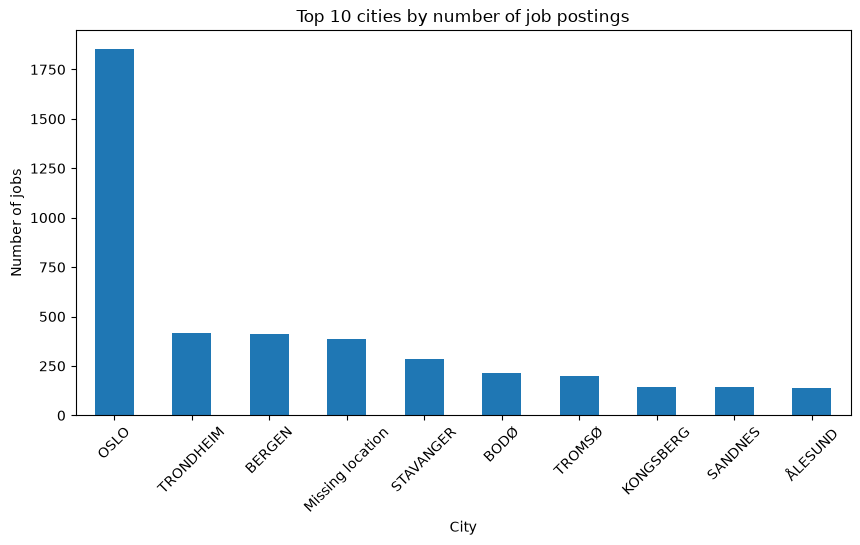

In [64]:
import matplotlib.pyplot as plt

city_counts = df["city"].value_counts().head(10)

plt.figure(figsize=(10,5))
city_counts.plot(kind="bar")
plt.title("Top 10 cities by number of job postings")
plt.xlabel("City")
plt.ylabel("Number of jobs")
plt.xticks(rotation=45)
plt.show()

In [65]:
df["skills"].head(10)

0    Arkiv, Brukerstøtte, Digitalisering, Dokumenta...
1    Helsehus, Kommunal helse, Korttidsopphold, Med...
2    Ambulant arbeid, Barn, Barne- og ungdomspsykol...
3    Barne- og ungdomspsykiatri, Behandling, Lege, ...
4    Brukermedvirkning, Eldreomsorg, Helse, Helsefa...
5    Blodprøvetaking, Helse, Miljøarbeid, Omsorg, P...
6    Elektro, Forsvar, Industriteknikk, Ingeniør, L...
7    Bolig, Funksjonsnedsettelse, Helse, Miljøterap...
8    Barn, Familiearbeid, Forebyggende arbeid, Hels...
9    autorisasjon, barn og unge, familiearbeid, for...
Name: skills, dtype: str

In [66]:
skills_df = df["skills"].str.split(", ").explode()
skills_df.head(20)

0                        Arkiv
0                 Brukerstøtte
0               Digitalisering
0    Dokumentasjonsforvaltning
0      Informasjonsforvaltning
0                  Innsynskrav
0                Journalføring
0             Kvalitetssikring
0            Offentlig journal
0                     Rådgiver
1                     Helsehus
1               Kommunal helse
1              Korttidsopphold
1         Medikamenthåndtering
1                   Nattarbeid
1               Nattsykepleier
1                  Observasjon
1            Pasientoppfølging
1               Rehabilitering
1                   Sykepleier
Name: skills, dtype: str

In [67]:
skills_df.value_counts().head(20)

skills
Omsorg                   1471
Kundeservice             1396
Helse                    1106
Butikk                   1057
Salg                      981
Leder                     895
Service                   839
Kontor                    808
Sykepleier                716
Kasse                     636
Butikkmedarbeider         632
Personalansvar            618
Administrasjon            571
Sykehus                   565
Assistent                 543
Veiledning                533
Barn                      519
Tverrfaglig samarbeid     476
Ledelse                   475
Rådgiver                  472
Name: count, dtype: int64

In [68]:
df[df["skills"].str.contains("AI|data|Python|SQL|digital|analyse|analyse", case = False, na=False)].shape

(1236, 12)

In [69]:
ai_jobs = df[df["skills"].str.contains(
    "AI|data|Python|SQL|digital|analyse",
    case = False,
    na=False
)]

ai_jobs["skills"].head(20)

0      Arkiv, Brukerstøtte, Digitalisering, Dokumenta...
25     Analytiker, Dataanalyse, Forsvar, Ingeniør, Lo...
26     Distribusjon, Forsendelse, Kontorarbeid, Logis...
43     Analyse, BW4HANA, Business Objects, ERP, Forsv...
51     Administrasjon, Digital kompetanse, Excel, Hel...
54     Analyse, Dataanalyse, Kontor, Kvalitativ analy...
60     Dataregister, Førstekonsulent, Juridisk, Konto...
109    AI, B2B, CRM, Digital markedsføring, Hjemmekon...
113    Butikk, Forretningsanalyse, KPI, Prosjektledel...
115    AI, Analyse, Bank, Compliance, Finans, Internr...
123    Analyse, Forbedringsleder, LEAN, Leder, Logist...
129    Administrasjon, Assistent, Butikk, Buyer, ERP,...
136    CRM, Datadrevet markedsføring, Kommunikasjon, ...
148    AI-utvikler, Dataplattform, KI-utvikler, Kunst...
161    Analyse, Jus, Kontor, Merverdiavgift, Offentli...
174    B2B, Digital markedsføring, Kommunikasjon, Kon...
189    AI-utvikling, Fullstack utvikler, Media, Princ...
190    Automatisering, Avdeling

In [70]:
skills_table = df[["job_id","city","title","skills"]].copy()

skills_table["skills"] = skills_table["skills"].str.split(", ")

skills_table = skills_table.explode("skills")

skills_table.head(20)

,job_id,city,title,skills
0,0112ac82-d16e-449b-8ae0-17e5bb874829,LØRENSKOG,Vil du være med å styrke vår informasjonsforva...,Arkiv
0,0112ac82-d16e-449b-8ae0-17e5bb874829,LØRENSKOG,Vil du være med å styrke vår informasjonsforva...,Brukerstøtte
0,0112ac82-d16e-449b-8ae0-17e5bb874829,LØRENSKOG,Vil du være med å styrke vår informasjonsforva...,Digitalisering
0,0112ac82-d16e-449b-8ae0-17e5bb874829,LØRENSKOG,Vil du være med å styrke vår informasjonsforva...,Dokumentasjonsforvaltning
0,0112ac82-d16e-449b-8ae0-17e5bb874829,LØRENSKOG,Vil du være med å styrke vår informasjonsforva...,Informasjonsforvaltning
0,0112ac82-d16e-449b-8ae0-17e5bb874829,LØRENSKOG,Vil du være med å styrke vår informasjonsforva...,Innsynskrav
0,0112ac82-d16e-449b-8ae0-17e5bb874829,LØRENSKOG,Vil du være med å styrke vår informasjonsforva...,Journalføring
0,0112ac82-d16e-449b-8ae0-17e5bb874829,LØRENSKOG,Vil du være med å styrke vår informasjonsforva...,Kvalitetssikring
0,0112ac82-d16e-449b-8ae0-17e5bb874829,LØRENSKOG,Vil du være med å styrke vår informasjonsforva...,Offentlig journal
0,0112ac82-d16e-449b-8ae0-17e5bb874829,LØRENSKOG,Vil du være med å styrke vår informasjonsforva...,Rådgiver


In [71]:
skills_table = skills_table.rename(
    columns={"skills": "skill"}
)

In [72]:
skills_table.to_csv("../data/processed/job_skills.csv", index=False)

In [73]:
skills_table.shape

(95324, 4)